In [4]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [5]:
Dengu_Data_set=pd.read_csv("Dengue_diseases_dataset_modified (1).csv")
Dengu_Data_set

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1
...,...,...,...,...,...,...,...,...,...
984,27,Female,11.6,9400.0,1,1,400000.0,39.9,0
985,19,Female,15.8,7400.0,1,1,320560.0,56.0,0
986,54,Female,11.9,7500.0,1,1,345000.0,44.4,0
987,34,Male,14.6,9500.0,1,1,326000.0,41.9,0


In [6]:
Dengu_Data_set.isna().sum()

age                             0
gender                          0
hemoglobin_g_dl                 0
wbc_count                      24
differential_count              0
rbc_count                       0
platelet_count                 16
platelet_distribution_width    19
dengue_label                    0
dtype: int64

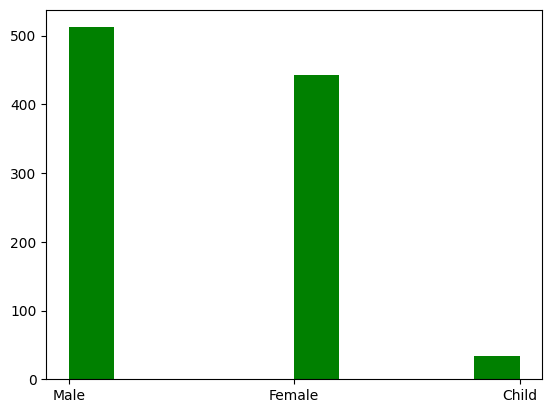

In [7]:
plt.hist(data=Dengu_Data_set,x='gender',color='green')
plt.show()

In [8]:
print((Dengu_Data_set['gender']=='Child').sum())

34


In [9]:
Dengu_Data_set['wbc_count'] = Dengu_Data_set['wbc_count'].fillna(value =  Dengu_Data_set['wbc_count'].median())
Dengu_Data_set['platelet_count'] = Dengu_Data_set['platelet_count'].fillna(value =  Dengu_Data_set['platelet_count'].median())

In [10]:
Dengu_Data_set.isna().sum()

age                             0
gender                          0
hemoglobin_g_dl                 0
wbc_count                       0
differential_count              0
rbc_count                       0
platelet_count                  0
platelet_distribution_width    19
dengue_label                    0
dtype: int64

In [11]:
Dengu_Data_set['wbc_count']

0      2200.0
1      3000.0
2      3300.0
3      3500.0
4      3100.0
        ...  
984    9400.0
985    7400.0
986    7500.0
987    9500.0
988    6700.0
Name: wbc_count, Length: 989, dtype: float64

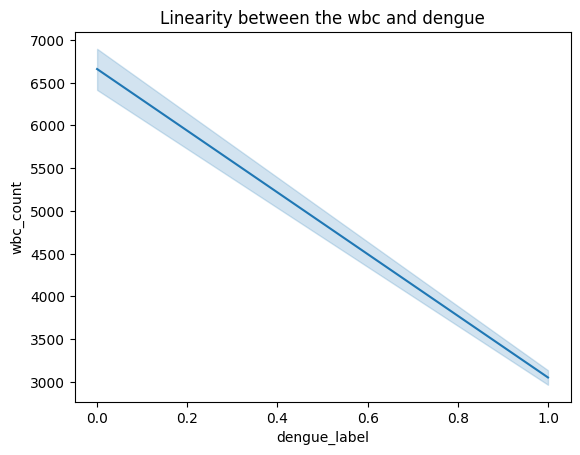

In [12]:
sns.lineplot(Dengu_Data_set,x='dengue_label',y = 'wbc_count')
plt.title('Linearity between the wbc and dengue')
plt.show()

In [13]:
Dengu_Data_set['gender'] = Dengu_Data_set['gender'] .apply( lambda x : 1 if x== "Male" else 0)

### Why we change ? because before building a model we have to change all tthe catagorical data into numerical data for Maintaining the efficience of the model

In [14]:
Dengu_Data_set['gender']

0      1
1      1
2      0
3      0
4      0
      ..
984    0
985    0
986    0
987    1
988    1
Name: gender, Length: 989, dtype: int64

<Axes: >

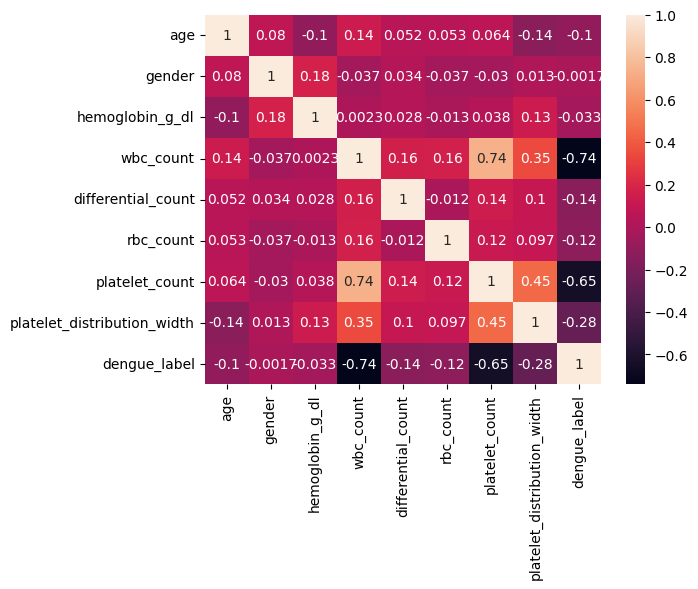

In [15]:
k = Dengu_Data_set.corr()
sns.heatmap(k,annot=True)

### From the above understanding that the wbc_count and the platelet counts are highly negatively correlated with dengu label

In [16]:
x = Dengu_Data_set[['wbc_count','platelet_count']]
y = Dengu_Data_set['dengue_label']

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix ,classification_report,accuracy_score,roc_auc_score,roc_curve
from sklearn.model_selection import train_test_split

In [38]:
Model = LogisticRegression()

In [39]:
Model.fit(x,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size = 0.2,random_state = 5)

In [41]:
predicted_y = Model.predict(X_test)
predicted_y

array([0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1])

In [42]:
accuracy_score(y_test,predicted_y)

0.8838383838383839

In [43]:
trained_Y= Model.predict(X_train)
trained_Y

array([0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,

In [44]:
accuracy_score(y_train,trained_Y)

0.9152970922882427

### This is a Trainind Data's Classification Report

In [45]:
print(classification_report(y_train,trained_Y))

              precision    recall  f1-score   support

           0       0.92      0.83      0.87       276
           1       0.91      0.96      0.94       515

    accuracy                           0.92       791
   macro avg       0.92      0.90      0.90       791
weighted avg       0.92      0.92      0.91       791



In [46]:
print(confusion_matrix(y_train,trained_Y))

[[229  47]
 [ 20 495]]


#### Training Data's Confustion matrix clearly show us that fn(false negative)& fp (false positives) are very low 

#### SO There is less risk which is only 20 risky predictions we got

In [47]:
print(classification_report(y_test,predicted_y))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82        69
           1       0.88      0.95      0.91       129

    accuracy                           0.88       198
   macro avg       0.88      0.86      0.87       198
weighted avg       0.88      0.88      0.88       198



### The above Classification Report is for test Data's classification Report

In [48]:
print(confusion_matrix(y_test,predicted_y))

[[ 53  16]
 [  7 122]]


#### So here we have only 7 risky predictions we got

#### THIS IS ROC_AUC_SCORE WITH ROC_CURVE FOR TRAINING DATA

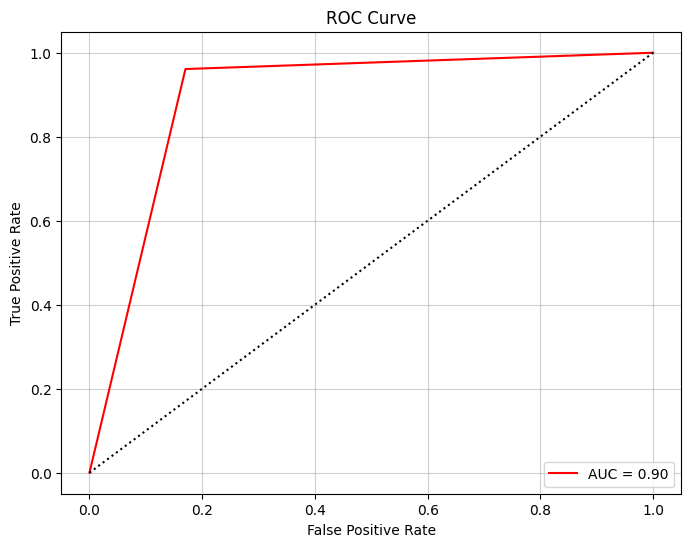

In [87]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
y_probs = Model.predict_proba(x)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train,trained_Y)
auc_score = roc_auc_score(y_train,trained_Y)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', label=f'AUC = {auc_score:.2f}' )
plt.plot([0, 1], [0, 1], color='black', linestyle=':')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.6)
plt.show()
print()

#### THIS IS ROC_AUC_SCORE WITH ROC_CURVE FOR TEST DATA

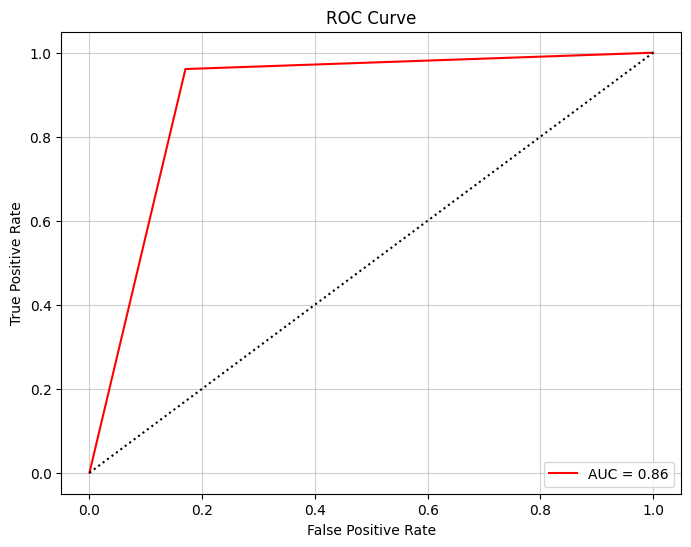

In [88]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
y_probs = Model.predict_proba(x)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train,trained_Y)
auc_score = roc_auc_score(y_test,predicted_y)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', label=f'AUC = {auc_score:.2f}' )
plt.plot([0, 1], [0, 1], color='black', linestyle=':')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.6)
plt.show()
print()

## So FROm the above comaprision we had lost 0.04  of Auc score

In [115]:
from  pickle import dump

In [119]:
dump(Model,open('Dengue_prediction.pkl',mode = 'wb'))